# SHAPE-MaP Deep Learning Analysis Pipeline

**Analysis of 497 RNA mutant oligos vs Wild-Type**

This notebook performs:
1. Data loading and preprocessing
2. Identification of mutations causing biggest SHAPE changes
3. Clustering to find groups with similar patterns
4. Deep learning for pattern discovery
5. Regional analysis of SHAPE reactivity

---

## Part 1: Setup and Installation

**Note**: If you get version compatibility errors, skip the first cell and just run the imports cell

In [1]:
pip install numpy pandas matplotlib scikit-learn scipy umap-learn torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Try to import seaborn, but it's optional
try:
    import seaborn as sns
    sns.set_palette("husl")
    HAS_SEABORN = True
    print("✓ Seaborn loaded")
except (ImportError, AttributeError) as e:
    print("Note: Seaborn not available (will use matplotlib only)")
    HAS_SEABORN = False

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

# Try UMAP
import umap.umap_ as umap

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Set style
plt.style.use('default')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

print("\n✓ All core packages imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✓ Seaborn loaded



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/miniconda3/envs/shape-analysis/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/miniconda3/envs/shape-analysis/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/miniconda3/envs/shape-analysis/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    s


✓ All core packages imported successfully!
PyTorch version: 2.2.2
Device: CPU


## Part 2: Load and Process Data

In [3]:
# Load data
data_path = '/Users/herber4/Desktop/Dissertation/chapter_three/claude/data_4_claude.txt'  # Update this path if needed

print("Loading SHAPE data...")
df = pd.read_csv(data_path, sep='\t')

print(f"\n✓ Loaded {len(df):,} rows")
print(f"✓ Columns: {len(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loading SHAPE data...

✓ Loaded 84,490 rows
✓ Columns: 38

First few rows:


,sample,spearman_cor,similarity_score,annot,name,K700E_vs_WT_dPSI,K700E_vs_WT_p_value,MT_vs_WT_dPSI,MT_vs_WT_p_value,Nucleotide,...,Denatured_rate,Denatured_off_target_mapped_depth,Denatured_low_mapq_mapped_depth,Denatured_mapped_depth,Reactivity_profile,Std_err,HQ_profile,HQ_stderr,Norm_profile,Norm_stderr
0,One_1,0.707273,5.367551,Branch_Point,Rep_One_MAP_mut_BP_1,0.130469,0.00398,0.172286,0.007664,56,...,NaN,0,0,0,0.000481,0.000295,0.000481,0.000295,0.158697,0.097330
1,One_1,0.707273,5.367551,Branch_Point,Rep_One_MAP_mut_BP_1,0.130469,0.00398,0.172286,0.007664,66,...,NaN,0,0,0,0.000460,0.000353,0.000460,0.000353,0.151769,0.116466
2,One_1,0.707273,5.367551,Branch_Point,Rep_One_MAP_mut_BP_1,0.130469,0.00398,0.172286,0.007664,67,...,NaN,0,0,0,0.001238,0.000289,0.001238,0.000289,0.408456,0.095350
3,One_1,0.707273,5.367551,Branch_Point,Rep_One_MAP_mut_BP_1,0.130469,0.00398,0.172286,0.007664,68,...,NaN,0,0,0,0.001262,0.000232,0.001262,0.000232,0.416374,0.076544
4,One_1,0.707273,5.367551,Branch_Point,Rep_One_MAP_mut_BP_1,0.130469,0.00398,0.172286,0.007664,69,...,NaN,0,0,0,0.005400,0.000474,0.005400,0.000474,1.781634,0.156388


In [4]:
# Data summary
n_samples = df['sample'].nunique()
n_positions = df['Nucleotide'].nunique()
n_annots = df['annot'].nunique()

print(f"Dataset Summary:")
print(f"  Unique samples: {n_samples}")
print(f"  Nucleotide positions: {n_positions}")
print(f"  Unique annotations: {n_annots}")
print(f"\nTop 20 annotation categories:")
print(df['annot'].value_counts().head(20))

Dataset Summary:
  Unique samples: 497
  Nucleotide positions: 170
  Unique annotations: 156

Top 20 annotation categories:
annot
Branch_Point                 7820
NAGNAG                       5100
C3SS_2_TGF_C3SS              3740
Can_2_TGF_Can                2380
Weaken_C3SS_Py               2040
Weaken_Can_Py                2040
Dinuc_Shuffle                1700
Move_C3SS                    1700
Strengthen_C3SS_Py           1360
RBP_Block_Four               1360
RBP_Block_One                1360
RBP_Block_Three              1360
RBP_Block_Two                1360
C3SS_KO                      1360
Strengthen_Can_Py            1020
Can_KO                       1020
Swap_C3SS_2_Can               680
RBP_Two_RBP_four_au_rich      340
RBP_Two_RBP_four_shuffle      340
RBP_Two_RBP_three_au_rich     340
Name: count, dtype: int64


In [5]:
# Reshape data to matrix format
# Rows = samples, Columns = positions

print("Reshaping data to matrix format...")
shape_matrix_df = df.pivot(index='sample', columns='Nucleotide', values='Norm_profile')

shape_matrix = shape_matrix_df.values
samples = shape_matrix_df.index.tolist()
positions = shape_matrix_df.columns.tolist()

print(f"\n✓ Matrix shape: {shape_matrix.shape}")
print(f"  (Samples: {len(samples)}, Positions: {len(positions)})")

# Check for missing values
n_missing = np.isnan(shape_matrix).sum()
if n_missing > 0:
    print(f"\n⚠ Warning: {n_missing} missing values detected ({100*n_missing/shape_matrix.size:.2f}%)")
    print("  Imputing with median values...")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    shape_matrix = imputer.fit_transform(shape_matrix)
    print("  ✓ Imputation complete")
else:
    print("\n✓ No missing values")

Reshaping data to matrix format...

✓ Matrix shape: (497, 170)
  (Samples: 497, Positions: 170)

⚠ Warning: 5572 missing values detected (6.59%)
  Imputing with median values...
  ✓ Imputation complete


In [6]:
# Extract annotation information for each sample
print("Extracting annotations...")
annotations = df.groupby('sample')['annot'].first().to_dict()

print(f"\n✓ Extracted annotations for {len(annotations)} samples")
print(f"\nTop 10 annotation categories:")
annot_counts = pd.Series(list(annotations.values())).value_counts()
print(annot_counts.head(10))

Extracting annotations...

✓ Extracted annotations for 497 samples

Top 10 annotation categories:
Branch_Point          46
NAGNAG                30
C3SS_2_TGF_C3SS       22
Can_2_TGF_Can         14
Weaken_C3SS_Py        12
Weaken_Can_Py         12
Dinuc_Shuffle         10
Move_C3SS             10
Strengthen_C3SS_Py     8
RBP_Block_Four         8
Name: count, dtype: int64


## Part 3: Wild-Type Analysis

In [7]:
# Identify wild-type samples
wt_samples = ['One_205', 'Two_205']

print("Looking for wild-type samples...")
wt_indices = [i for i, s in enumerate(samples) if s in wt_samples]

if len(wt_indices) == 0:
    print("\n⚠ Warning: Wild-type samples not found!")
    print("   Searching for samples containing '205'...")
    wt_indices = [i for i, s in enumerate(samples) if '205' in s]
    wt_samples = [samples[i] for i in wt_indices]

print(f"\n✓ Found {len(wt_indices)} wild-type samples:")
for idx in wt_indices:
    print(f"  - {samples[idx]}")

# Compute average WT profile
wt_profile = np.mean(shape_matrix[wt_indices, :], axis=0)
print(f"\n✓ Computed average WT profile")

Looking for wild-type samples...

✓ Found 1 wild-type samples:
  - Two_205

✓ Computed average WT profile


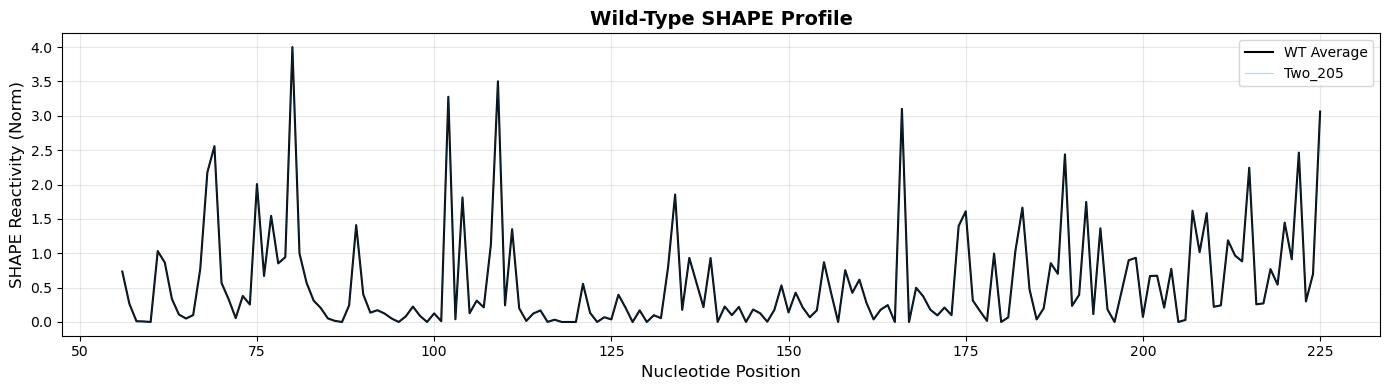

WT profile statistics:
  Mean reactivity: 0.5759
  Std deviation: 0.7531
  Min: 0.0000
  Max: 4.0000


In [8]:
# Plot wild-type profile
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(positions, wt_profile, 'k-', linewidth=1.5, label='WT Average')

# Plot individual WT replicates
for idx in wt_indices:
    ax.plot(positions, shape_matrix[idx, :], alpha=0.3, linewidth=0.8, 
            label=samples[idx])

ax.set_xlabel('Nucleotide Position', fontsize=12)
ax.set_ylabel('SHAPE Reactivity (Norm)', fontsize=12)
ax.set_title('Wild-Type SHAPE Profile', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"WT profile statistics:")
print(f"  Mean reactivity: {wt_profile.mean():.4f}")
print(f"  Std deviation: {wt_profile.std():.4f}")
print(f"  Min: {wt_profile.min():.4f}")
print(f"  Max: {wt_profile.max():.4f}")

## Part 4: Compute Differences from Wild-Type

In [9]:
# Compute difference matrix (each sample - WT)
print("Computing differences from wild-type...")
diff_matrix = shape_matrix - wt_profile[np.newaxis, :]

# Compute distance metrics
mean_abs_diff = np.abs(diff_matrix).mean(axis=1)
max_abs_diff = np.abs(diff_matrix).max(axis=1)
rmsd = np.sqrt(np.mean(diff_matrix**2, axis=1))

print(f"\n✓ Computed difference profiles")
print(f"\nDistance metrics summary:")
print(f"  Mean |diff|: {mean_abs_diff.mean():.4f} ± {mean_abs_diff.std():.4f}")
print(f"  Max |diff|:  {max_abs_diff.mean():.4f} ± {max_abs_diff.std():.4f}")
print(f"  RMSD:        {rmsd.mean():.4f} ± {rmsd.std():.4f}")

Computing differences from wild-type...

✓ Computed difference profiles

Distance metrics summary:
  Mean |diff|: 0.3313 ± 0.0962
  Max |diff|:  2.9500 ± 0.6784
  RMSD:        0.5647 ± 0.1418


In [10]:
# Create results dataframe
results_df = pd.DataFrame({
    'sample': samples,
    'annotation': [annotations.get(s, 'Unknown') for s in samples],
    'mean_abs_diff': mean_abs_diff,
    'max_abs_diff': max_abs_diff,
    'rmsd': rmsd,
    'is_wt': [s in wt_samples for s in samples]
})

# Sort by RMSD
results_df = results_df.sort_values('rmsd', ascending=False)

print("\nTop 20 most different samples from WT (by RMSD):")
print(results_df.head(20)[['sample', 'annotation', 'rmsd']])


Top 20 most different samples from WT (by RMSD):
      sample        annotation      rmsd
174   One_32      DHDDS_Intron  1.075326
423   Two_32      DHDDS_Intron  1.034805
392  Two_229     Dinuc_Shuffle  0.985664
427   Two_36       ODF2_Intron  0.982926
422   Two_31      GAPDH_Intron  0.981903
173   One_31      GAPDH_Intron  0.980170
143  One_229     Dinuc_Shuffle  0.962495
424   Two_33     EIF4G1_Intron  0.959370
274  Two_122  AT_to_GC_50pct_4  0.957549
418   Two_28         Move_C3SS  0.956750
24   One_120  AT_to_GC_50pct_2  0.955811
175   One_33     EIF4G1_Intron  0.954380
395  Two_231     Dinuc_Shuffle  0.944926
428   Two_37      TRNT1_Intron  0.938344
272  Two_120  AT_to_GC_50pct_2  0.936696
146  One_231     Dinuc_Shuffle  0.926742
179   One_37      TRNT1_Intron  0.918042
178   One_36       ODF2_Intron  0.914845
419   Two_29      AP5Z1_Intron  0.914165
172   One_30     ARMCX3_Intron  0.905727


## Part 5: Visualize Top Different Mutants

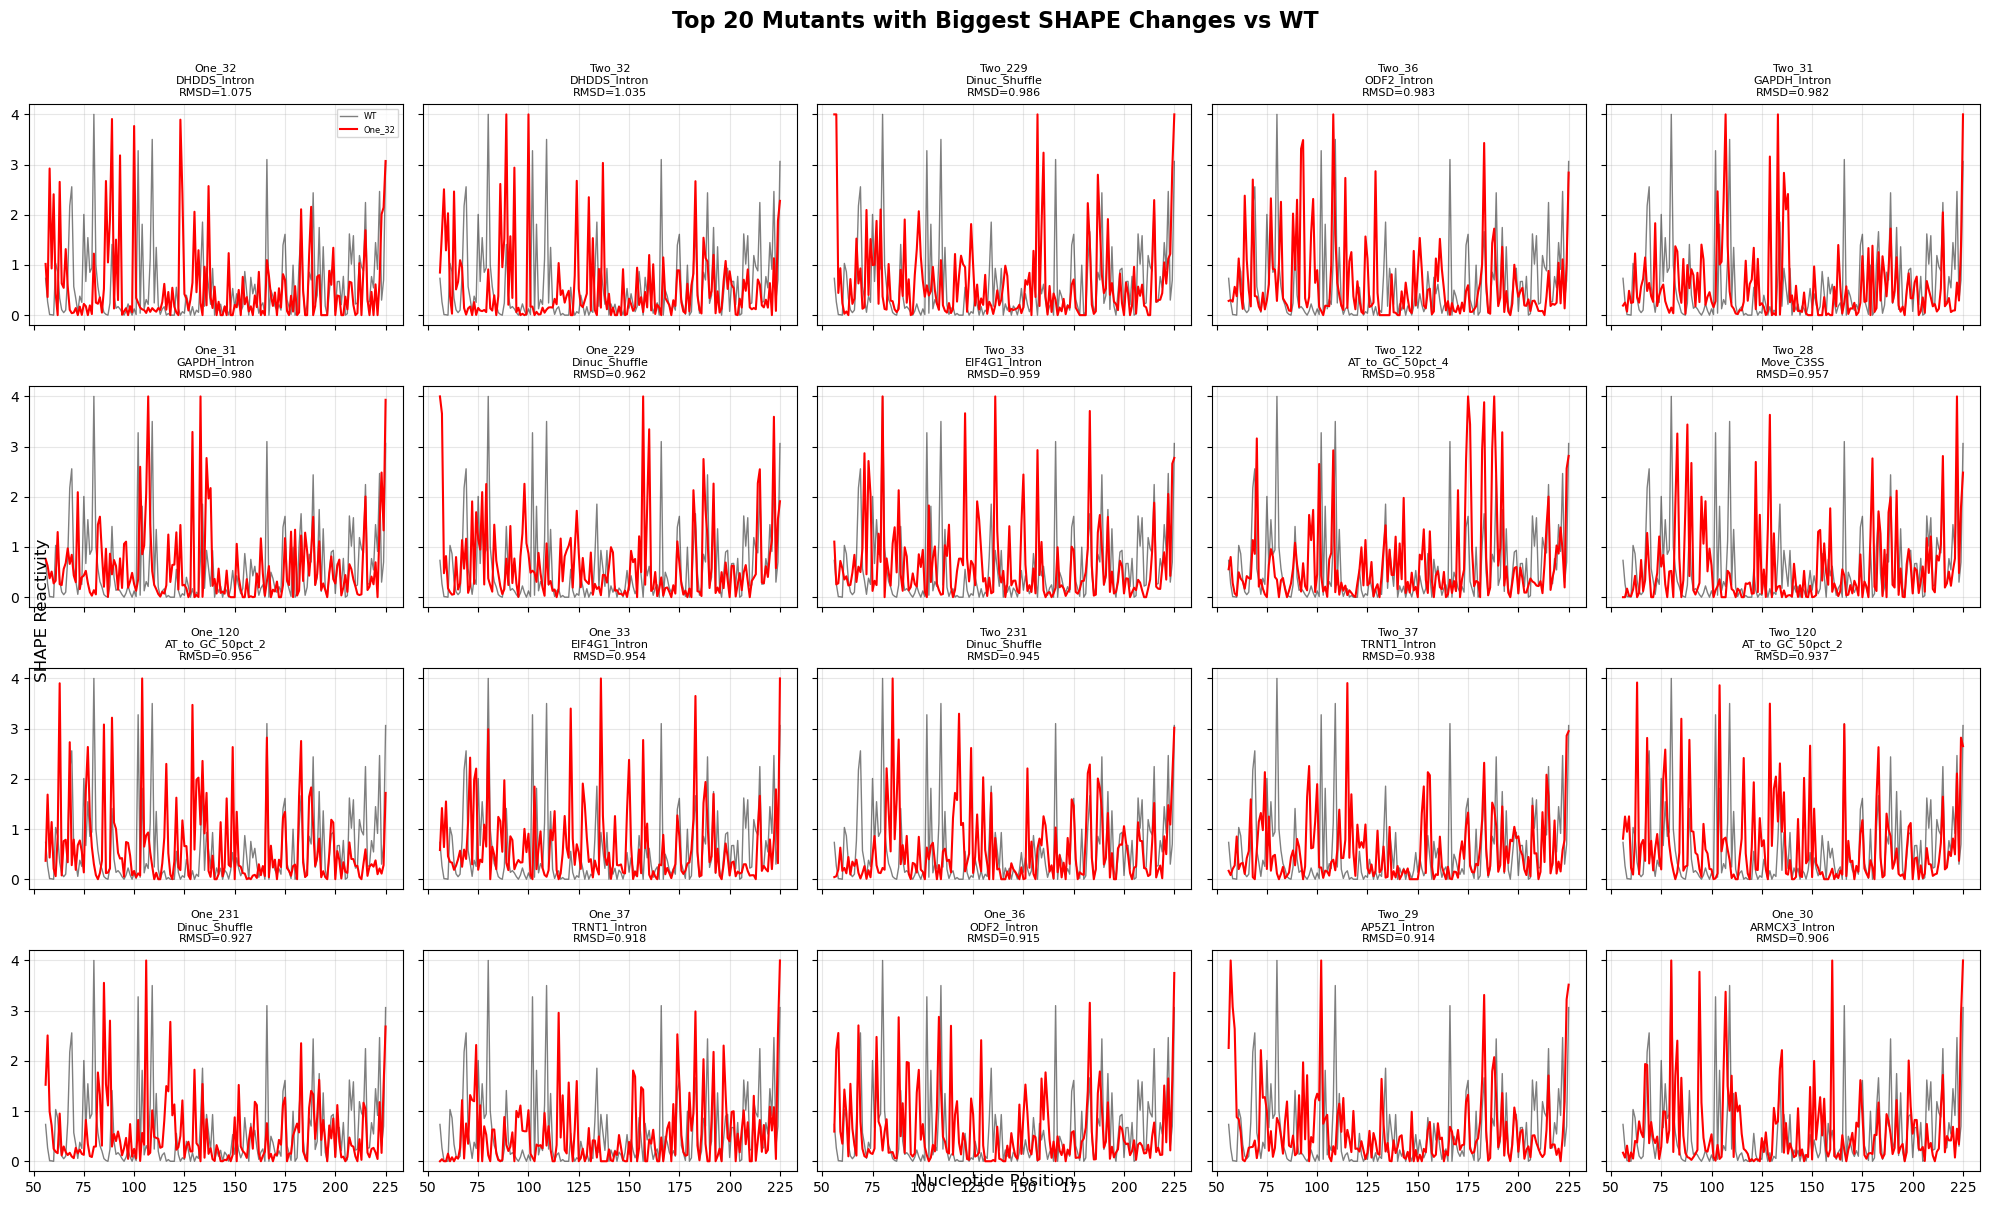

In [11]:
# Plot top 20 most different samples
top_n = 20
top_indices = np.argsort(rmsd)[::-1][:top_n]

fig, axes = plt.subplots(4, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (sample_idx, ax) in enumerate(zip(top_indices, axes)):
    sample_name = samples[sample_idx]
    annot = annotations.get(sample_name, 'Unknown')
    
    # Plot WT and mutant profiles
    ax.plot(positions, wt_profile, 'k-', alpha=0.5, linewidth=1, label='WT')
    ax.plot(positions, shape_matrix[sample_idx, :], 'r-', 
            linewidth=1.5, label=sample_name)
    
    # Add title with info
    title = f"{sample_name}\n{annot}\nRMSD={rmsd[sample_idx]:.3f}"
    ax.set_title(title, fontsize=8)
    ax.grid(alpha=0.3)
    
    if idx == 0:
        ax.legend(fontsize=6)

fig.suptitle('Top 20 Mutants with Biggest SHAPE Changes vs WT', 
             fontsize=16, fontweight='bold', y=1.00)
fig.text(0.5, 0.02, 'Nucleotide Position', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'SHAPE Reactivity', va='center', rotation='vertical', fontsize=12)
plt.tight_layout()
plt.show()

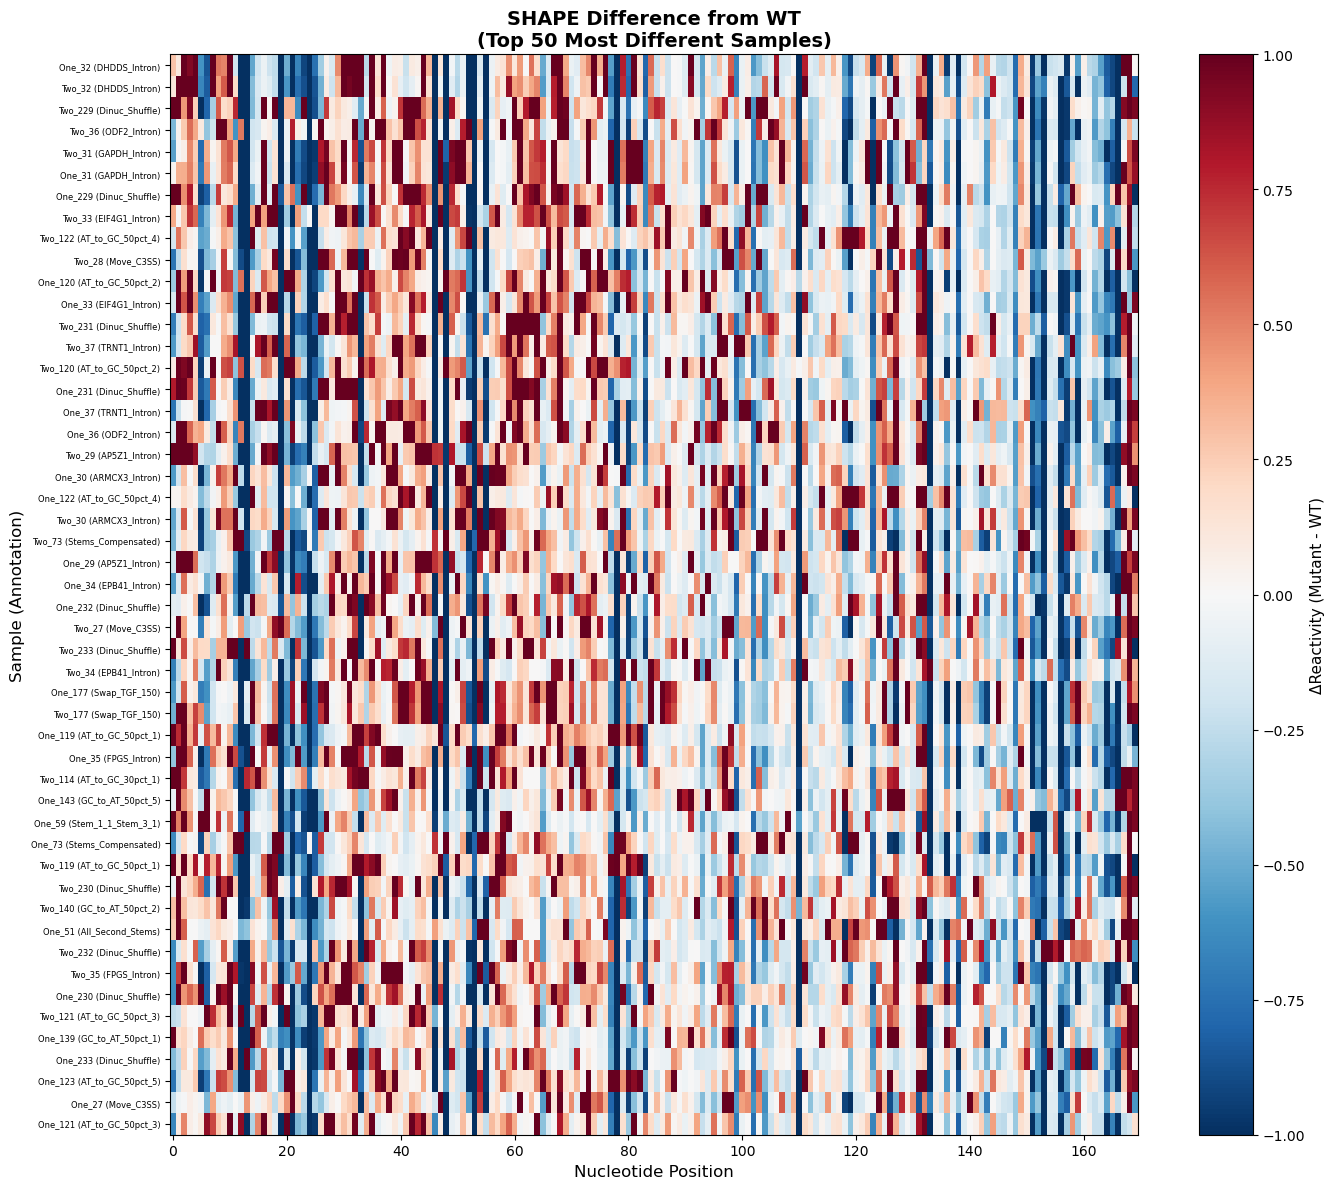

In [12]:
# Heatmap of difference profiles for top 50 samples
top_n = 50
top_indices = np.argsort(rmsd)[::-1][:top_n]

diff_data = diff_matrix[top_indices, :]
sample_labels = [f"{samples[i]} ({annotations.get(samples[i], 'Unknown')})" 
                 for i in top_indices]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(diff_data, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_yticks(range(len(sample_labels)))
ax.set_yticklabels(sample_labels, fontsize=6)
ax.set_xlabel('Nucleotide Position', fontsize=12)
ax.set_ylabel('Sample (Annotation)', fontsize=12)
ax.set_title(f'SHAPE Difference from WT\n(Top {top_n} Most Different Samples)', 
            fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('ΔReactivity (Mutant - WT)', fontsize=11)
plt.tight_layout()
plt.show()

## Part 6: Distribution Analysis by Annotation

In [13]:
# Analyze RMSD by annotation category
annot_stats = results_df.groupby('annotation')['rmsd'].agg(['mean', 'std', 'count'])
annot_stats = annot_stats.sort_values('mean', ascending=False)

print("\nTop 20 annotations by mean RMSD from WT:")
print(annot_stats.head(20))


Top 20 annotations by mean RMSD from WT:
                       mean       std  count
annotation                                  
DHDDS_Intron       1.055065  0.028653      2
GAPDH_Intron       0.981036  0.001225      2
EIF4G1_Intron      0.956875  0.003529      2
ODF2_Intron        0.948885  0.048140      2
AT_to_GC_50pct_2   0.946254  0.013516      2
AT_to_GC_50pct_4   0.930946  0.037623      2
TRNT1_Intron       0.928193  0.014356      2
AP5Z1_Intron       0.905897  0.011692      2
ARMCX3_Intron      0.902944  0.003937      2
EPB41_Intron       0.884772  0.014686      2
Dinuc_Shuffle      0.876610  0.076078     10
Swap_TGF_150       0.865927  0.007551      2
Stems_Compensated  0.864326  0.049639      2
AT_to_GC_50pct_1   0.833878  0.031297      2
FPGS_Intron        0.825203  0.039088      2
AT_to_GC_30pct_1   0.809314  0.056620      2
AT_to_GC_50pct_3   0.787766  0.012298      2
GC_to_AT_50pct_5   0.779606  0.091485      2
AT_to_GC_50pct_5   0.763315  0.031180      2
Stem_1_1_Stem

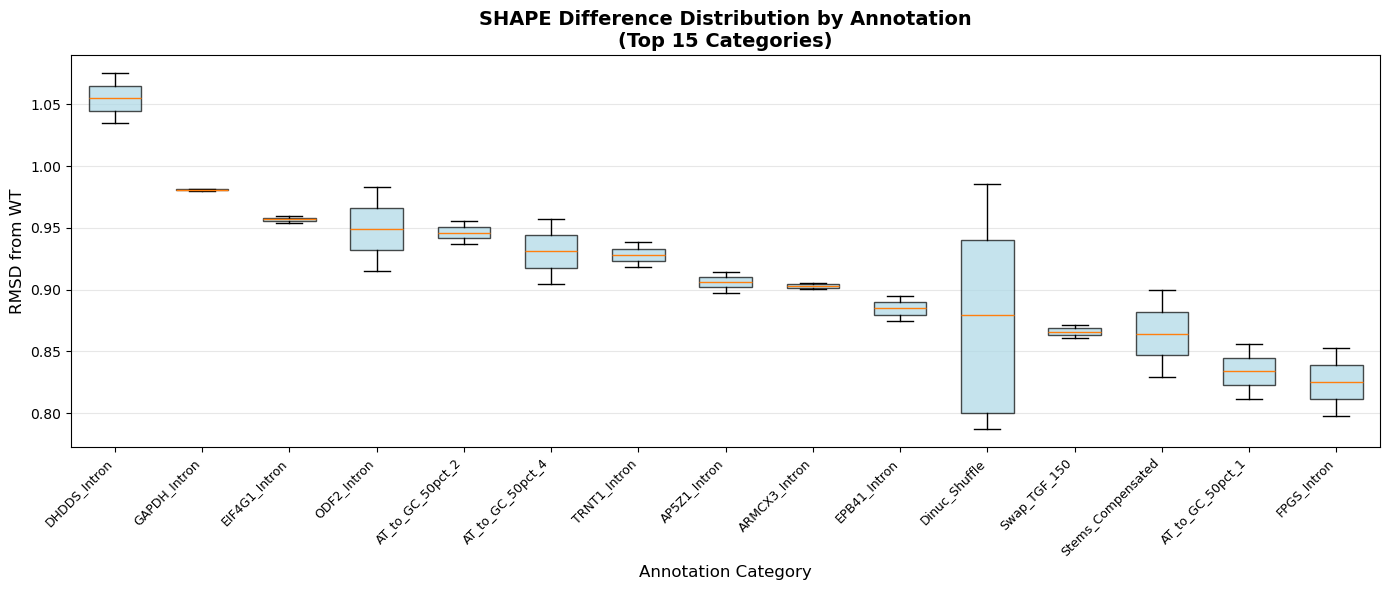

In [14]:
# Box plot of RMSD by top annotation categories
top_annots = annot_stats.head(15).index.tolist()
plot_data = results_df[results_df['annotation'].isin(top_annots)]

fig, ax = plt.subplots(figsize=(14, 6))

# Manual boxplot using matplotlib
positions_box = []
data_box = []
for i, annot in enumerate(top_annots):
    annot_data = plot_data[plot_data['annotation'] == annot]['rmsd'].values
    if len(annot_data) > 0:
        positions_box.append(i)
        data_box.append(annot_data)

bp = ax.boxplot(data_box, positions=positions_box, widths=0.6, patch_artist=True)

# Color boxes
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.set_xticks(positions_box)
ax.set_xticklabels(top_annots, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('RMSD from WT', fontsize=12)
ax.set_xlabel('Annotation Category', fontsize=12)
ax.set_title('SHAPE Difference Distribution by Annotation\n(Top 15 Categories)', 
            fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Part 7: Regional Analysis - Find Hotspots

In [15]:
# Sliding window analysis to find regional hotspots
window_size = 10
n_samples, n_positions_mat = diff_matrix.shape
n_windows = n_positions_mat - window_size + 1

print(f"Performing sliding window analysis...")
print(f"  Window size: {window_size} nucleotides")
print(f"  Number of windows: {n_windows}")

# Compute windowed RMSD
windowed_rmsd = np.zeros((n_samples, n_windows))

for i in range(n_windows):
    window_diff = diff_matrix[:, i:i+window_size]
    windowed_rmsd[:, i] = np.sqrt(np.mean(window_diff**2, axis=1))

# Find regions with highest variability across samples
window_variance = np.var(windowed_rmsd, axis=0)
window_mean_rmsd = np.mean(windowed_rmsd, axis=0)

print(f"\n✓ Windowed analysis complete")

Performing sliding window analysis...
  Window size: 10 nucleotides
  Number of windows: 161

✓ Windowed analysis complete


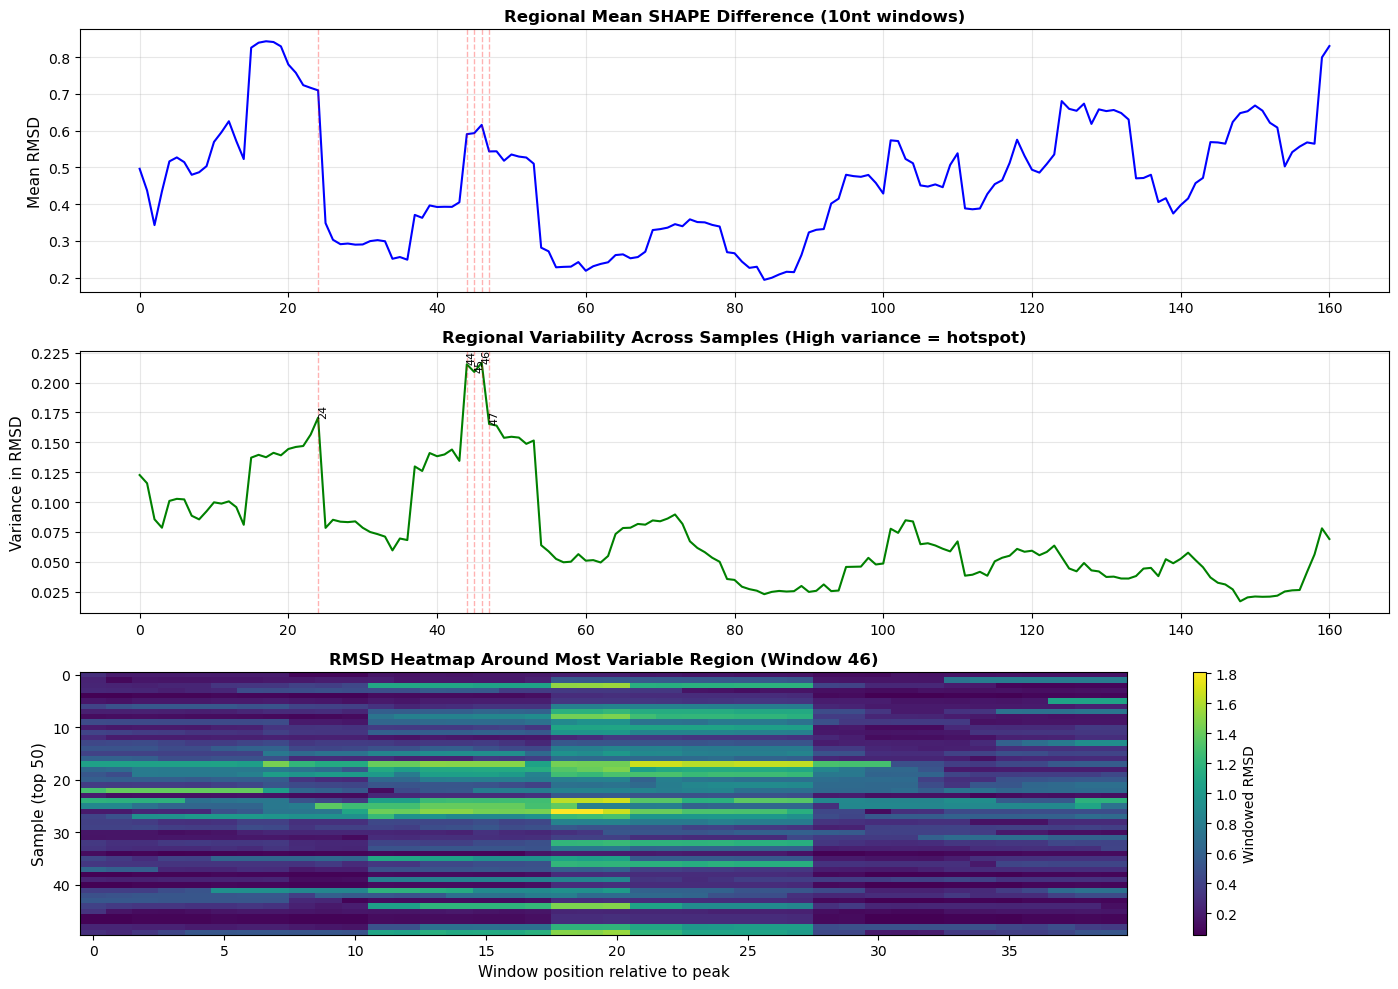


Top 5 most variable regions (window start positions):
  1. Position 46-56 (variance=0.2166)
  2. Position 44-54 (variance=0.2154)
  3. Position 45-55 (variance=0.2089)
  4. Position 24-34 (variance=0.1707)
  5. Position 47-57 (variance=0.1653)


In [16]:
# Plot regional variability
top_regions = np.argsort(window_variance)[::-1][:5]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Mean RMSD across positions
ax = axes[0]
ax.plot(window_mean_rmsd, 'b-', linewidth=1.5)
for region in top_regions:
    ax.axvline(region, color='r', alpha=0.3, linestyle='--', linewidth=1)
ax.set_ylabel('Mean RMSD', fontsize=11)
ax.set_title('Regional Mean SHAPE Difference (10nt windows)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Plot 2: Variance across positions
ax = axes[1]
ax.plot(window_variance, 'g-', linewidth=1.5)
for region in top_regions:
    ax.axvline(region, color='r', alpha=0.3, linestyle='--', linewidth=1)
    ax.text(region, window_variance[region], f'{region}', 
           fontsize=8, rotation=90, va='bottom')
ax.set_ylabel('Variance in RMSD', fontsize=11)
ax.set_title('Regional Variability Across Samples (High variance = hotspot)', 
            fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Plot 3: Heatmap of most variable region
ax = axes[2]
top_region = top_regions[0]
region_start = max(0, top_region - 20)
region_end = min(n_windows, top_region + 20)
region_data = windowed_rmsd[:50, region_start:region_end]  # Top 50 samples

im = ax.imshow(region_data, aspect='auto', cmap='viridis')
ax.set_ylabel('Sample (top 50)', fontsize=11)
ax.set_xlabel('Window position relative to peak', fontsize=11)
ax.set_title(f'RMSD Heatmap Around Most Variable Region (Window {top_region})', 
            fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Windowed RMSD')

plt.tight_layout()
plt.show()

print(f"\nTop 5 most variable regions (window start positions):")
for i, region in enumerate(top_regions, 1):
    print(f"  {i}. Position {region}-{region+window_size} (variance={window_variance[region]:.4f})")

## Part 8: Unsupervised Clustering

Performing PCA...

✓ PCA complete
  Variance explained by first 10 PCs: 0.461


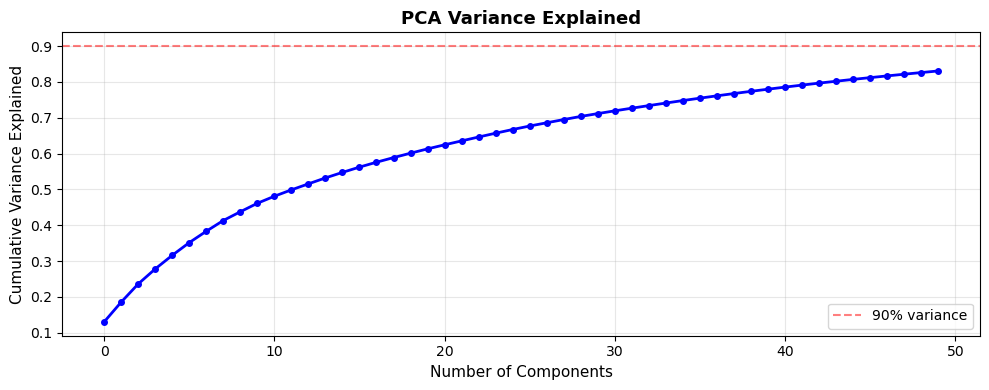

In [17]:
# Dimensionality reduction with PCA
print("Performing PCA...")
pca = PCA(n_components=50)
X_pca = pca.fit_transform(diff_matrix)

print(f"\n✓ PCA complete")
print(f"  Variance explained by first 10 PCs: {pca.explained_variance_ratio_[:10].sum():.3f}")

# Plot variance explained
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.cumsum(pca.explained_variance_ratio_), 'b-o', linewidth=2, markersize=4)
ax.axhline(0.9, color='r', linestyle='--', alpha=0.5, label='90% variance')
ax.set_xlabel('Number of Components', fontsize=11)
ax.set_ylabel('Cumulative Variance Explained', fontsize=11)
ax.set_title('PCA Variance Explained', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Dimensionality reduction for visualization
print("Computing 2D embedding for visualization...")

print("  Using UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, n_components=2)
embedding = reducer.fit_transform(diff_matrix)
embedding_method = "UMAP"

print("  Using t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedding = tsne.fit_transform(diff_matrix)
embedding_method = "t-SNE"

print(f"✓ {embedding_method} complete")

Computing 2D embedding for visualization...
  Using UMAP...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  Using t-SNE (this may take a minute)...
✓ t-SNE complete


In [19]:
# K-means clustering
n_clusters = 8
print(f"\nPerforming K-means clustering with {n_clusters} clusters...")

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(diff_matrix)

# Print cluster sizes
unique, counts = np.unique(cluster_labels, return_counts=True)
print(f"\n✓ Clustering complete")
print("\nCluster sizes:")
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} samples")


Performing K-means clustering with 8 clusters...

✓ Clustering complete

Cluster sizes:
  Cluster 0: 49 samples
  Cluster 1: 94 samples
  Cluster 2: 74 samples
  Cluster 3: 50 samples
  Cluster 4: 45 samples
  Cluster 5: 60 samples
  Cluster 6: 95 samples
  Cluster 7: 30 samples


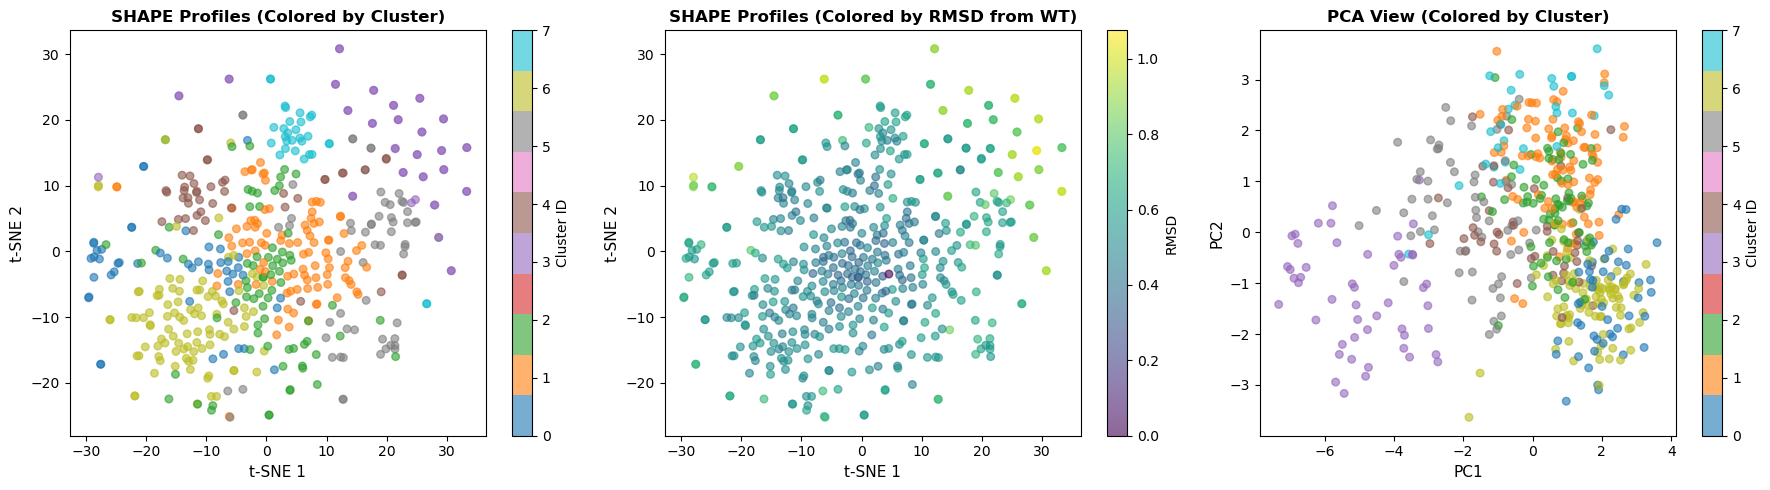

In [20]:
# Visualize clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Colored by cluster
ax = axes[0]
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], 
                    c=cluster_labels, cmap='tab10', s=30, alpha=0.6)
ax.set_xlabel(f'{embedding_method} 1', fontsize=11)
ax.set_ylabel(f'{embedding_method} 2', fontsize=11)
ax.set_title('SHAPE Profiles (Colored by Cluster)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster ID')

# Plot 2: Colored by RMSD
ax = axes[1]
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], 
                    c=rmsd, cmap='viridis', s=30, alpha=0.6)
ax.set_xlabel(f'{embedding_method} 1', fontsize=11)
ax.set_ylabel(f'{embedding_method} 2', fontsize=11)
ax.set_title('SHAPE Profiles (Colored by RMSD from WT)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='RMSD')

# Plot 3: PCA view
ax = axes[2]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=cluster_labels, cmap='tab10', s=30, alpha=0.6)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('PCA View (Colored by Cluster)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster ID')

plt.tight_layout()
plt.show()

## Part 9: Cluster Characterization

In [21]:
# Analyze what distinguishes each cluster
cluster_results = []

for cluster_id in range(n_clusters):
    cluster_mask = cluster_labels == cluster_id
    cluster_samples = [samples[i] for i in np.where(cluster_mask)[0]]
    
    # Get annotations
    cluster_annots = [annotations.get(s, 'Unknown') for s in cluster_samples]
    annot_counts = pd.Series(cluster_annots).value_counts()
    
    # Compute mean profile
    cluster_mean_profile = diff_matrix[cluster_mask, :].mean(axis=0)
    
    # Find top differential positions
    abs_profile = np.abs(cluster_mean_profile)
    top_positions_idx = np.argsort(abs_profile)[::-1][:10]
    top_pos_values = [positions[i] for i in top_positions_idx]
    
    cluster_results.append({
        'cluster_id': cluster_id,
        'n_samples': cluster_mask.sum(),
        'top_annotations': annot_counts.head(5).to_dict(),
        'mean_rmsd': rmsd[cluster_mask].mean(),
        'std_rmsd': rmsd[cluster_mask].std(),
        'top_positions': top_pos_values,
        'mean_profile': cluster_mean_profile
    })

# Print cluster summaries
for res in cluster_results:
    print(f"\n{'='*60}")
    print(f"CLUSTER {res['cluster_id']}")
    print(f"{'='*60}")
    print(f"  N samples: {res['n_samples']}")
    print(f"  Mean RMSD: {res['mean_rmsd']:.4f} ± {res['std_rmsd']:.4f}")
    print(f"\n  Top annotations:")
    for annot, count in res['top_annotations'].items():
        print(f"    - {annot}: {count} samples")
    print(f"\n  Top differential positions: {res['top_positions'][:5]}")


CLUSTER 0
  N samples: 49
  Mean RMSD: 0.5693 ± 0.1058

  Top annotations:
    - Can_2_TGF_Can: 8 samples
    - Weaken_Can_Py: 5 samples
    - Swap_C3SS_2_Can: 4 samples
    - C3SS_2_TGF_C3SS: 2 samples
    - Can_2_TGF_C3SS: 2 samples

  Top differential positions: [189, 80, 166, 209, 224]

CLUSTER 1
  N samples: 94
  Mean RMSD: 0.4676 ± 0.0947

  Top annotations:
    - Branch_Point: 16 samples
    - RBP_Block_Three: 7 samples
    - Strengthen_Can_Py: 6 samples
    - Can_2_TGF_Can: 4 samples
    - NAGNAG: 4 samples

  Top differential positions: [224, 189, 109, 209, 212]

CLUSTER 2
  N samples: 74
  Mean RMSD: 0.5045 ± 0.0930

  Top annotations:
    - Branch_Point: 8 samples
    - RBP_Block_One: 5 samples
    - Weaken_Can_Py: 4 samples
    - NAGNAG: 4 samples
    - C3SS_2_TGF_C3SS: 3 samples

  Top differential positions: [224, 80, 189, 209, 212]

CLUSTER 3
  N samples: 50
  Mean RMSD: 0.8612 ± 0.1034

  Top annotations:
    - Dinuc_Shuffle: 9 samples
    - AT_to_GC_20pct_4: 2 samples

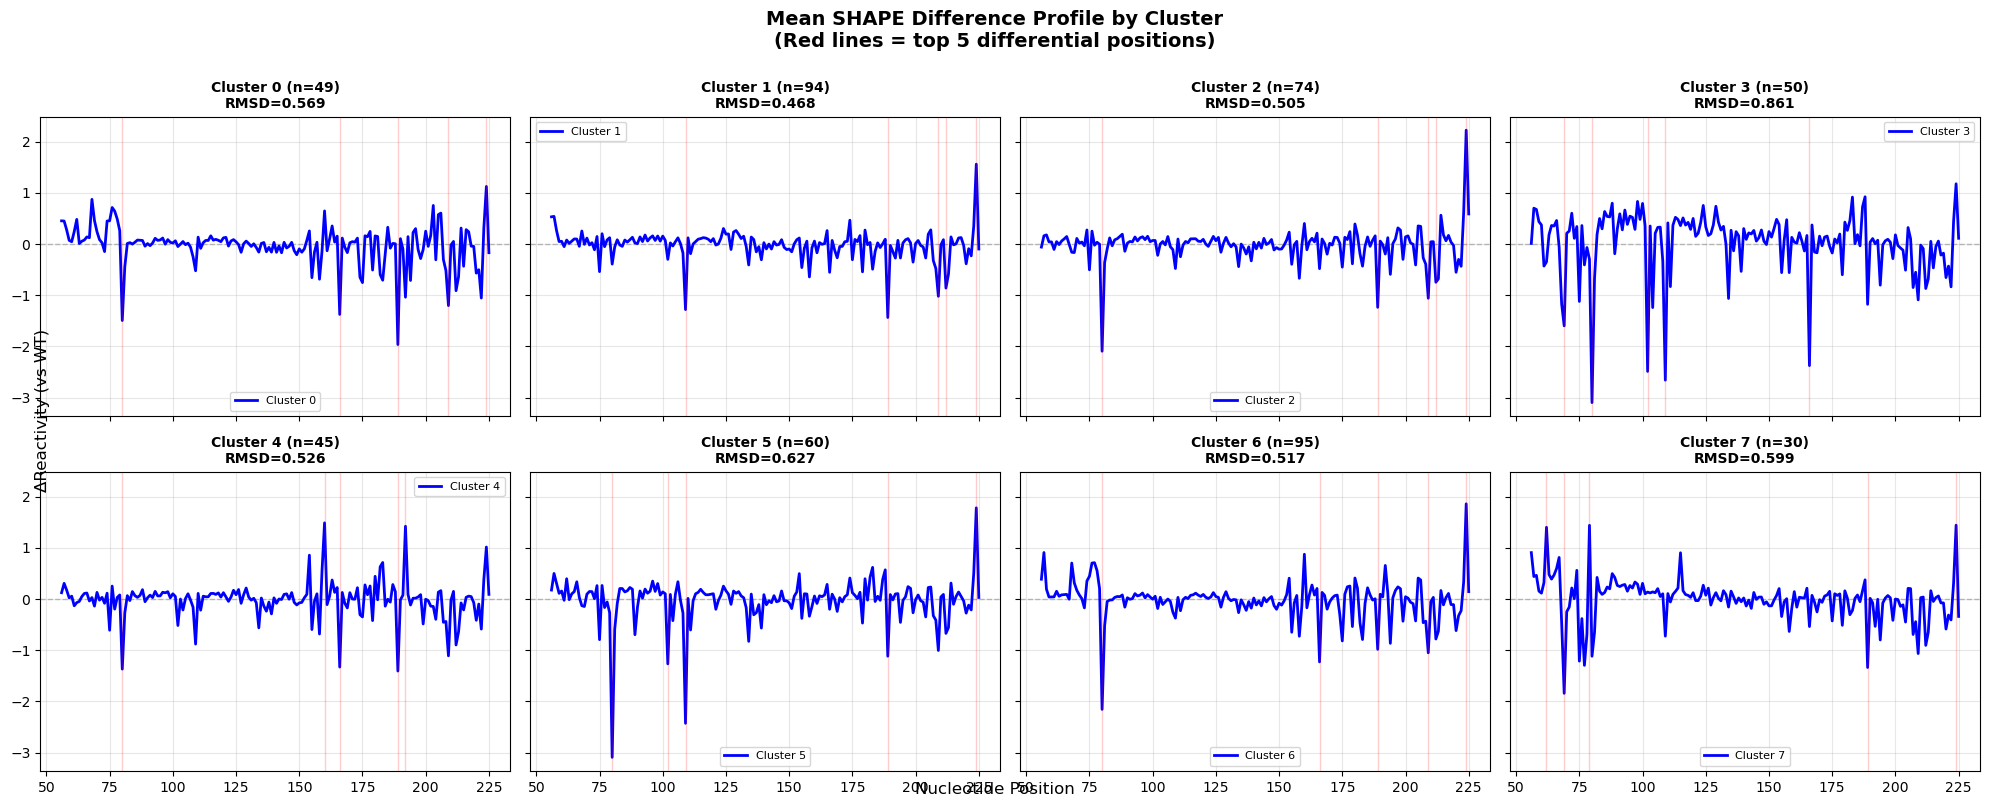

In [22]:
# Plot mean profiles for each cluster
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, res in enumerate(cluster_results):
    ax = axes[idx]
    
    # Plot WT baseline
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Plot mean cluster profile
    ax.plot(positions, res['mean_profile'], 'b-', linewidth=2, 
           label=f"Cluster {res['cluster_id']}")
    
    # Highlight top differential positions
    top_5_idx = np.argsort(np.abs(res['mean_profile']))[::-1][:5]
    for i in top_5_idx:
        ax.axvline(positions[i], color='r', alpha=0.2, linewidth=1)
    
    ax.set_title(f"Cluster {res['cluster_id']} (n={res['n_samples']})\n" +
                f"RMSD={res['mean_rmsd']:.3f}", fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Mean SHAPE Difference Profile by Cluster\n(Red lines = top 5 differential positions)', 
            fontsize=14, fontweight='bold', y=1.00)
fig.text(0.5, 0.02, 'Nucleotide Position', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'ΔReactivity (vs WT)', va='center', rotation='vertical', fontsize=12)
plt.tight_layout()
plt.show()

## Part 10: Deep Learning - Autoencoder

In [23]:
# Define autoencoder
class SHAPEAutoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=32):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, encoding_dim),
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, input_dim),
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        return self.encoder(x)

print("✓ Autoencoder model defined")

✓ Autoencoder model defined


In [24]:
# Prepare data for autoencoder
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Convert to tensors
X_train = torch.FloatTensor(diff_matrix).to(device)

# Initialize model
input_dim = diff_matrix.shape[1]
encoding_dim = 32

autoencoder = SHAPEAutoencoder(input_dim, encoding_dim).to(device)
print(f"\nModel architecture:")
print(autoencoder)

# Count parameters
n_params = sum(p.numel() for p in autoencoder.parameters())
print(f"\nTotal parameters: {n_params:,}")

Using device: cpu

Model architecture:
SHAPEAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=170, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=170, bias=True)
  )
)

Total parameters: 64,586


In [25]:
torch.set_num_threads(8)
#torch.set_num_interop_threads(10)
autoencoder = torch.compile(SHAPEAutoencoder)

# Train autoencoder
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

epochs = 100
batch_size = 256

print(f"Training autoencoder for {epochs} epochs...\n")

losses = []
autoencoder.train()

for epoch in range(epochs):
    # Mini-batch training
    epoch_loss = 0
    n_batches = 0
    
    for i in range(0, len(X_train), batch_size):
        batch = X_train[i:i+batch_size]
        
        # Forward pass
        reconstructed = autoencoder(batch)
        loss = criterion(reconstructed, batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

print("\n✓ Training complete!")

OSError: source code not available

In [ ]:
# Plot training loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses, 'b-', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Autoencoder Training Loss', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Get encodings
autoencoder.eval()
with torch.no_grad():
    encodings = autoencoder.encode(X_train).cpu().numpy()

print(f"Encoded representation shape: {encodings.shape}")
print(f"Original shape: {diff_matrix.shape}")
print(f"Compression ratio: {diff_matrix.shape[1] / encodings.shape[1]:.1f}x")

In [ ]:
# Visualize encoded space
if HAS_UMAP:
    reducer_ae = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding_ae = reducer_ae.fit_transform(encodings)
else:
    tsne_ae = TSNE(n_components=2, random_state=42, perplexity=30)
    embedding_ae = tsne_ae.fit_transform(encodings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original space
ax = axes[0]
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], 
                    c=cluster_labels, cmap='tab10', s=30, alpha=0.6)
ax.set_xlabel(f'{embedding_method} 1', fontsize=11)
ax.set_ylabel(f'{embedding_method} 2', fontsize=11)
ax.set_title('Original SHAPE Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')

# Plot 2: Encoded space
ax = axes[1]
scatter = ax.scatter(embedding_ae[:, 0], embedding_ae[:, 1], 
                    c=cluster_labels, cmap='tab10', s=30, alpha=0.6)
ax.set_xlabel(f'{embedding_method} 1', fontsize=11)
ax.set_ylabel(f'{embedding_method} 2', fontsize=11)
ax.set_title('Autoencoder Latent Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.show()

## Part 11: Deep Learning - Attention Model

In [26]:
# Define attention-based classifier
class SHAPEAttentionClassifier(nn.Module):
    """
    Attention model that learns which positions are most important
    for predicting annotation categories
    """
    def __init__(self, input_dim, n_classes, hidden_dim=64):
        super().__init__()
        
        self.input_dim = input_dim
        
        # Position-wise transformation
        self.position_transform = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU()
        )
        
        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes)
        )
    
    def forward(self, x):
        # x shape: (batch, input_dim)
        batch_size = x.shape[0]
        
        # Transform each position
        x_reshaped = x.unsqueeze(-1)  # (batch, input_dim, 1)
        position_features = self.position_transform(x_reshaped)  # (batch, input_dim, hidden_dim)
        
        # Compute attention weights
        attention_scores = self.attention(position_features).squeeze(-1)  # (batch, input_dim)
        attention_weights = F.softmax(attention_scores, dim=1)  # (batch, input_dim)
        
        # Apply attention
        weighted_features = (position_features * attention_weights.unsqueeze(-1)).sum(dim=1)  # (batch, hidden_dim)
        
        # Classify
        output = self.classifier(weighted_features)
        
        return output, attention_weights

print("✓ Attention model defined")

✓ Attention model defined


In [27]:
# Prepare labels for classification
# Use top 10 most common annotations
top_n_annots = 10
annot_series = pd.Series([annotations.get(s, 'Unknown') for s in samples])
top_annots_list = annot_series.value_counts().head(top_n_annots).index.tolist()

# Filter to only samples with these annotations
mask = annot_series.isin(top_annots_list)
filtered_indices = np.where(mask)[0]

X_filtered = diff_matrix[filtered_indices, :]
y_annots = annot_series[mask].values

# Create label mapping
label_map = {annot: i for i, annot in enumerate(top_annots_list)}
y_labels = np.array([label_map[a] for a in y_annots])

print(f"Filtered dataset:")
print(f"  Samples: {len(X_filtered)}")
print(f"  Classes: {len(top_annots_list)}")
print(f"\nClass distribution:")
for annot in top_annots_list:
    count = (y_annots == annot).sum()
    print(f"  {annot}: {count} samples")

Filtered dataset:
  Samples: 172
  Classes: 10

Class distribution:
  Branch_Point: 46 samples
  NAGNAG: 30 samples
  C3SS_2_TGF_C3SS: 22 samples
  Can_2_TGF_Can: 14 samples
  Weaken_C3SS_Py: 12 samples
  Weaken_Can_Py: 12 samples
  Dinuc_Shuffle: 10 samples
  Move_C3SS: 10 samples
  Strengthen_C3SS_Py: 8 samples
  RBP_Block_Four: 8 samples


In [28]:
# Split data
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_filtered, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_clf).to(device)
X_test_t = torch.FloatTensor(X_test_clf).to(device)
y_train_t = torch.LongTensor(y_train_clf).to(device)
y_test_t = torch.LongTensor(y_test_clf).to(device)

print(f"Training set: {len(X_train_t)} samples")
print(f"Test set: {len(X_test_t)} samples")

Training set: 137 samples
Test set: 35 samples


In [29]:
# Initialize attention model
n_classes = len(top_annots_list)
attention_model = SHAPEAttentionClassifier(input_dim, n_classes, hidden_dim=64).to(device)

print("Attention model:")
print(attention_model)

n_params_att = sum(p.numel() for p in attention_model.parameters())
print(f"\nTotal parameters: {n_params_att:,}")

Attention model:
SHAPEAttentionClassifier(
  (position_transform): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
  )
  (attention): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=10, bias=True)
  )
)

Total parameters: 8,811


In [ ]:
# Train attention model
criterion_clf = nn.CrossEntropyLoss()
optimizer_clf = torch.optim.Adam(attention_model.parameters(), lr=0.001)

epochs_clf = 50
batch_size_clf = 16

print(f"Training attention classifier for {epochs_clf} epochs...\n")

train_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs_clf):
    attention_model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    # Training
    for i in range(0, len(X_train_t), batch_size_clf):
        batch_x = X_train_t[i:i+batch_size_clf]
        batch_y = y_train_t[i:i+batch_size_clf]
        
        # Forward
        outputs, _ = attention_model(batch_x)
        loss = criterion_clf(outputs, batch_y)
        
        # Backward
        optimizer_clf.zero_grad()
        loss.backward()
        optimizer_clf.step()
        
        epoch_loss += loss.item()
        
        # Accuracy
        _, predicted = outputs.max(1)
        total += batch_y.size(0)
        correct += predicted.eq(batch_y).sum().item()
    
    train_acc = 100. * correct / total
    avg_loss = epoch_loss / (len(X_train_t) // batch_size_clf + 1)
    
    # Evaluation
    attention_model.eval()
    with torch.no_grad():
        outputs_test, _ = attention_model(X_test_t)
        _, predicted_test = outputs_test.max(1)
        test_acc = 100. * predicted_test.eq(y_test_t).sum().item() / len(y_test_t)
    
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs_clf}")
        print(f"  Loss: {avg_loss:.4f}")
        print(f"  Train Acc: {train_acc:.2f}%")
        print(f"  Test Acc: {test_acc:.2f}%")

print("\n✓ Training complete!")

Training attention classifier for 50 epochs...



In [ ]:
# Plot training metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(train_losses, 'b-', linewidth=2, label='Training Loss')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Classification Loss', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(train_accs, 'b-', linewidth=2, label='Train Accuracy')
ax.plot(test_accs, 'r-', linewidth=2, label='Test Accuracy')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Classification Accuracy', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final test accuracy: {test_accs[-1]:.2f}%")

## Part 12: Attention Visualization - Important Positions

In [ ]:
# Extract attention weights for all samples
attention_model.eval()
with torch.no_grad():
    X_all_t = torch.FloatTensor(X_filtered).to(device)
    _, attention_weights_all = attention_model(X_all_t)
    attention_weights_np = attention_weights_all.cpu().numpy()

print(f"Attention weights shape: {attention_weights_np.shape}")

In [ ]:
# Plot average attention by class
fig, ax = plt.subplots(figsize=(14, 6))

for class_idx, annot in enumerate(top_annots_list[:5]):  # Top 5 classes
    class_mask = y_labels == class_idx
    mean_attention = attention_weights_np[class_mask, :].mean(axis=0)
    
    ax.plot(positions, mean_attention, linewidth=2, label=annot, alpha=0.7)

ax.set_xlabel('Nucleotide Position', fontsize=12)
ax.set_ylabel('Mean Attention Weight', fontsize=12)
ax.set_title('Average Attention by Annotation Class\n(Shows which positions are most important for each class)', 
            fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Find most important positions overall
mean_attention_overall = attention_weights_np.mean(axis=0)
top_attention_idx = np.argsort(mean_attention_overall)[::-1][:20]
top_attention_positions = [positions[i] for i in top_attention_idx]
top_attention_weights = mean_attention_overall[top_attention_idx]

print("\nTop 20 most important positions (by attention):")
for pos, weight in zip(top_attention_positions, top_attention_weights):
    print(f"  Position {pos}: {weight:.6f}")

In [ ]:
# Heatmap of attention weights
fig, ax = plt.subplots(figsize=(14, 8))

# Sample 50 random samples for visualization
sample_idx = np.random.choice(len(attention_weights_np), size=min(50, len(attention_weights_np)), replace=False)
attention_sample = attention_weights_np[sample_idx, :]

im = ax.imshow(attention_sample, aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Nucleotide Position', fontsize=11)
ax.set_ylabel('Sample', fontsize=11)
ax.set_title(f'Attention Heatmap ({len(sample_idx)} samples)\nBrighter = More Important', 
            fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.show()

## Part 13: Summary and Export Results

In [ ]:
# Create comprehensive results dataframe
final_results = pd.DataFrame({
    'sample': samples,
    'annotation': [annotations.get(s, 'Unknown') for s in samples],
    'rmsd_from_wt': rmsd,
    'mean_abs_diff': mean_abs_diff,
    'max_abs_diff': max_abs_diff,
    'cluster': cluster_labels,
    'embedding_1': embedding[:, 0],
    'embedding_2': embedding[:, 1],
    'pc1': X_pca[:, 0],
    'pc2': X_pca[:, 1]
})

# Add encoding features
for i in range(encoding_dim):
    final_results[f'encoding_{i}'] = encodings[:, i]

final_results.head()

In [ ]:
# Save results
final_results.to_csv('SHAPE_analysis_results.csv', index=False)
print("✓ Results saved to 'SHAPE_analysis_results.csv'")

# Save cluster info
cluster_info = []
for res in cluster_results:
    cluster_info.append({
        'cluster_id': res['cluster_id'],
        'n_samples': res['n_samples'],
        'mean_rmsd': res['mean_rmsd'],
        'std_rmsd': res['std_rmsd'],
        'top_annotation': list(res['top_annotations'].keys())[0] if res['top_annotations'] else 'None'
    })

cluster_df = pd.DataFrame(cluster_info)
cluster_df.to_csv('cluster_summary.csv', index=False)
print("✓ Cluster summary saved to 'cluster_summary.csv'")

In [ ]:
# Save models
torch.save(autoencoder.state_dict(), 'autoencoder_model.pt')
torch.save(attention_model.state_dict(), 'attention_model.pt')
print("✓ Models saved to .pt files")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print("\nGenerated files:")
print("  - SHAPE_analysis_results.csv")
print("  - cluster_summary.csv")
print("  - autoencoder_model.pt")
print("  - attention_model.pt")